In [1]:
import numpy as np
import xarray as xr

import matplotlib
from matplotlib import gridspec
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from shapely.geometry import Polygon

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT

import general_tools as gt
import plotting_tools as pt
from general_tools import constants

%load_ext autoreload
%autoreload 2

constants = {'g': 9.81,
             'Rd' : 287.,
             'cpd' : 1004.,
             'Lv': 2.5e6
            }

In [2]:
DATA_PATH = "/net/helium/atmosdyn/qnicolas/data_drybounds/"

# Load data

In [3]:
def calc_dry_upper_bound(T500):
    """Calculate the DSE-based dry adiabatic upper bound for a given 500 hPa temperature
    z_500 is taken proportional to T_500, with the proportionality constant calculated using the
    summer midlatitude land mean values (as in ZB23, eq. 7)."""
    z_500_mean = 5682
    T_500_mean = 258.8
    return T500 * (1 + constants['g'] / constants['cpd'] * z_500_mean / T_500_mean) 

def calc_dry_upper_bound_400(T400):
    """Calculate the DSE-based dry adiabatic upper bound for a given 400 hPa temperature
    z_400 is taken proportional to T_400, with the proportionality constant calculated using the
    summer midlatitude land mean values (as in ZB23, eq. 7)."""
    z_400_mean = 7331
    T_400_mean = 246.88
    return T400 * (1 + constants['g'] / constants['cpd'] * z_400_mean / T_400_mean) 
    
def calc_dry_upper_bound_300(T300):
    """Calculate the DSE-based dry adiabatic upper bound for a given 300 hPa temperature
    z_300 is taken proportional to T_300, with the proportionality constant calculated using the
    summer midlatitude land mean values (as in ZB23, eq. 7)."""
    z_300_mean = 9345
    T_300_mean = 231.7
    return T300 * (1 + constants['g'] / constants['cpd'] * z_300_mean / T_300_mean) 

def calc_dry_upper_bound_theta(T500):
    """Calculate the potential temperature-based dry adiabatic upper bound for a given 500 hPa temperature"""
    return T500 * (1000/500)**(constants['Rd']/constants['cpd'])

def calc_ZB23_upper_bound(T500):
    """Calculate the ZB23 upper bound (their eq. 3) for a given 500 hPa temperature"""
    return calc_dry_upper_bound(T500) + constants['Lv']/constants['cpd'] * gt.qsat(T500,500) 

In [4]:
e5_consts = xr.open_dataset(f"{DATA_PATH}/era5_constants.nc")
zsfc = e5_consts.Z.squeeze().drop_vars('time')
lsm = e5_consts.LSM.squeeze().drop_vars('time')

In [5]:
merged_t2max_global = xr.open_dataset(f"{DATA_PATH}/merged_T2mmax_global_JJA_2001-2021.nc")
# The following arrays are only defined over 40-65 degrees N
merged_T2mmax_midlats = xr.open_dataset(f"{DATA_PATH}/merged_T2mmax_midlats_JJA_2001-2021.nc")
superadibatic_strength_2m = merged_T2mmax_midlats.superadibatic_strength_2m
superadibatic_strength_lowestlev = merged_T2mmax_midlats.superadibatic_strength_lowestlev
PBL_HPA = merged_T2mmax_midlats.PBL_HPA_novirtual_T2m
PBL_HPA_e5 = xr.open_dataarray(f"{DATA_PATH}/PBL_HPA_e5_min1day_midlats_JJA_2001-2021.nc")

In [6]:
sshf_2001 = xr.open_dataarray(f"{DATA_PATH}/SSHF_T2mmax_midlats_JJA_2001.nc")

# Figure 1: Idealized skew-T

Initial q0: 0.0087 kg/kg
Initial q0: 0.0019 kg/kg


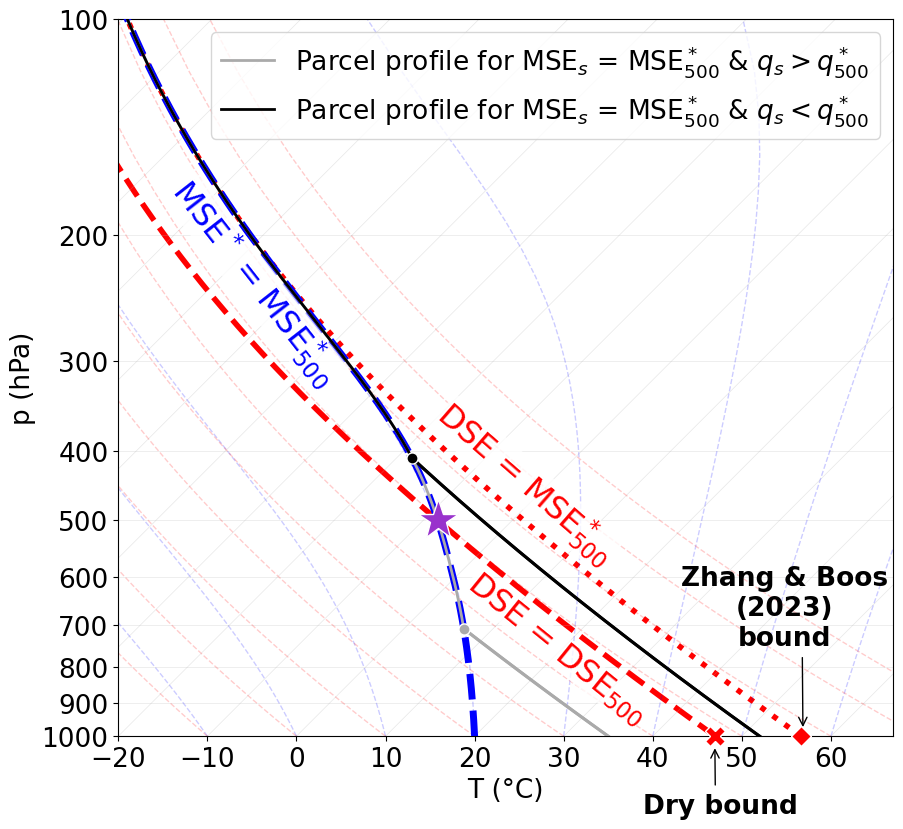

In [7]:
matplotlib.rcParams['font.size'] = 19
fig = plt.figure(figsize=(10, 10))
skew = SkewT(fig=fig, rotation=45)

# Calculate reference moist adiabat
ref_temp_sfc = 20.
# Calculate reference moist adiabat
MSEstar0 = gt.MSEstar(273.15 + ref_temp_sfc,0,1000.)
zz0,pz0,Tz0 = gt.calc_moist_adiabat(MSEstar0)
ref_temp_500 = np.interp(500.,pz0[::-1],Tz0[::-1])
z500 = np.interp(500.,pz0[::-1],zz0[::-1])

alpha = 1.

# Plot moist adiabat
skew.plot(pz0 * units.hPa, Tz0 * units.degK, color='b', ls = '--', lw=5, alpha=alpha,zorder=3)

# Plot dry adiabats
z500 = np.interp(500.,pz0[::-1],zz0[::-1])
T_constDSE_1 = (Tz0[-1] - constants['g'] * (zz0 - zz0[-1]) / constants['cpd'])
T_constDSE_2 = (ref_temp_500 - constants['g'] * (zz0 - z500) / constants['cpd'])
for Tprof,ls in zip([T_constDSE_1,T_constDSE_2],[':','--']):
    skew.plot(pz0 * units.hPa, Tprof * units.degK, color='r', ls = ls,lw=4, alpha=alpha,zorder=1)#, label= (Zhang & Boos 2023 bound)")

# Plot parcel profiles
for start_temp,color,desc in zip([273.15 + 35, 273.15 + 52],
                                 ['#AAAAAA','k'],
                                 [r"Parcel profile for MSE$_s$ = MSE$^*_{500}$ & $q_s > q^*_{500}$", r"Parcel profile for MSE$_s$ = MSE$^*_{500}$ & $q_s < q^*_{500}$"]
                                 ):
    pz,Tparc,i_sat = gt.calc_parcel_profile(start_temp, MSEstar0, ma_profile = (zz0, pz0,Tz0))
    skew.plot(pz * units.hPa, Tparc * units.degK, color=color, lw=2., label = desc,zorder=4)
    skew.plot(pz[:i_sat] * units.hPa, Tparc[:i_sat] * units.degK, color=color, lw=2.25)
    skew.plot(pz[i_sat] * units.hPa, Tparc[i_sat] * units.degK, 'o',zorder=5, color='w',markersize=8, markerfacecolor=color)


skew.plot(500. * units.hPa, ref_temp_500 * units.degK,marker='*',markersize=30, markerfacecolor='darkorchid',color='w',zorder=10)
for T0, marker,size in zip([T_constDSE_1[0], T_constDSE_2[0]],['D','X'],[10,15]):
    skew.plot(1000. * units.hPa, T0 * units.degK,marker=marker,markersize=size,color='w', markerfacecolor='r',zorder=10, clip_on=False)

ftz1 = 23
bbox_props = dict(facecolor='w', alpha=0.8, edgecolor='none',pad=0.1)
skew.ax.text(-5, 570, r"DSE = MSE$^*_{500}$",color='r', rotation=-41,fontsize=ftz1,bbox = bbox_props)
skew.ax.text(17, 960, r"DSE = DSE$_{500}$",color='r', rotation=-39,fontsize=ftz1,bbox = bbox_props)
skew.ax.text(-55, 320, r"MSE$^*$ = MSE$^*_{500}$",color='b', rotation=-52,fontsize=ftz1,bbox = bbox_props)

ftz2 = 19
x0 = T_constDSE_1[0] - 273.15 -.5
x1 = x0 -10
skew.ax.text(x1-1,760, "Zhang & Boos\n(2023)\nbound",color='k',fontsize=ftz2,fontweight='bold',ha='center',va = 'bottom')
arrowprops=dict(arrowstyle="<-",mutation_scale = 15)
skew.ax.annotate("", xy=(x1+1.5,770), xytext=(x0,980),arrowprops=arrowprops, xycoords='data')

x0 = T_constDSE_2[0] - 273.15+1
x1 = x0 +6
skew.ax.text(x1,1200, r"Dry bound",color='k',fontsize=ftz2,fontweight='bold',ha='center',va = 'top')
skew.ax.annotate("", xy=(x1-1.2,1180), xytext=(x0,1030),arrowprops=arrowprops,annotation_clip=False, xycoords='data')


skew.ax.legend(loc='upper right')#, frameon=False)
skew.ax.grid(linewidth=0.5,alpha=0.3)
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-20, 67)
skew.ax.set_ylabel("p (hPa)")
skew.ax.set_xlabel("T (°C)")


reference_profiles = np.arange(-20,81,10)
alpha_refprof = 0.2
lw_refprof = 1
skew.plot_moist_adiabats(t0 = reference_profiles * units.degC,alpha=alpha_refprof,linewidth=lw_refprof)
skew.plot_dry_adiabats(t0 = reference_profiles * units.degC,alpha=alpha_refprof,linewidth=lw_refprof)
# fig.savefig("figs/profiles.pdf",format='pdf',bbox_inches='tight')


# Figure 2: Histogram with profile

In [8]:
midlats = (lsm.lat <= 65) * (lsm.lat >= 40)
# Get joint histogram of T500 and DSE at 2m over midlatitude land points
hist_dse_t500 = gt.get_hist(merged_t2max_global.T500,
                            merged_t2max_global.T2M + zsfc/constants['cpd'],
                            lsm * midlats, 
                            dim_names=['T500','DSE2M'],
                            bins = (np.arange(200,301,.5), np.arange(250,351,.5))
                            )

In [9]:
kappa = constants['Rd']/constants['cpd']

era5_20140708T00 = xr.open_dataset(f"{DATA_PATH}/era5_modellevels_20140708T00.nc")
# Note there is a 0.5 degree discrepancy for the definition of the Elko location between this Fig and Fig. 3. 
# We realized this at the code cleaning phase, and decided not to change it because the ERA5 sounding is a bit noisier for
# Fig. 1 when using the -115.5 longitude, and did not have time to re-calculate the data for Fig. 3 with -116 longitude. The 
# changes there would most likely be very minimal.
lat,lon = 41, -116
elko_era5 = era5_20140708T00.sel(lat = lat, lon = lon, method='nearest').isel(time=0)
elko_era5['ZSFC'] = zsfc.sel(lat=lat, lon=lon, method='nearest')
elko_era5['THETA'] = elko_era5.T * (elko_era5.pressure / 1000. )**(-kappa)

# We do not use the same IGRA data as for Fig. 3 because we want maximum vertical resolution (the ones of Fig. 3 have slightly coarser vertical resolution)
elko_igra = xr.open_dataset(f"{DATA_PATH}/IGRA_USM00072582_2014-07-08.nc")
elko_igra['THETA'] = elko_igra.T * (elko_igra.pressure / 1000. )**(-kappa)

Text(0.025, 0.985, '(c)')

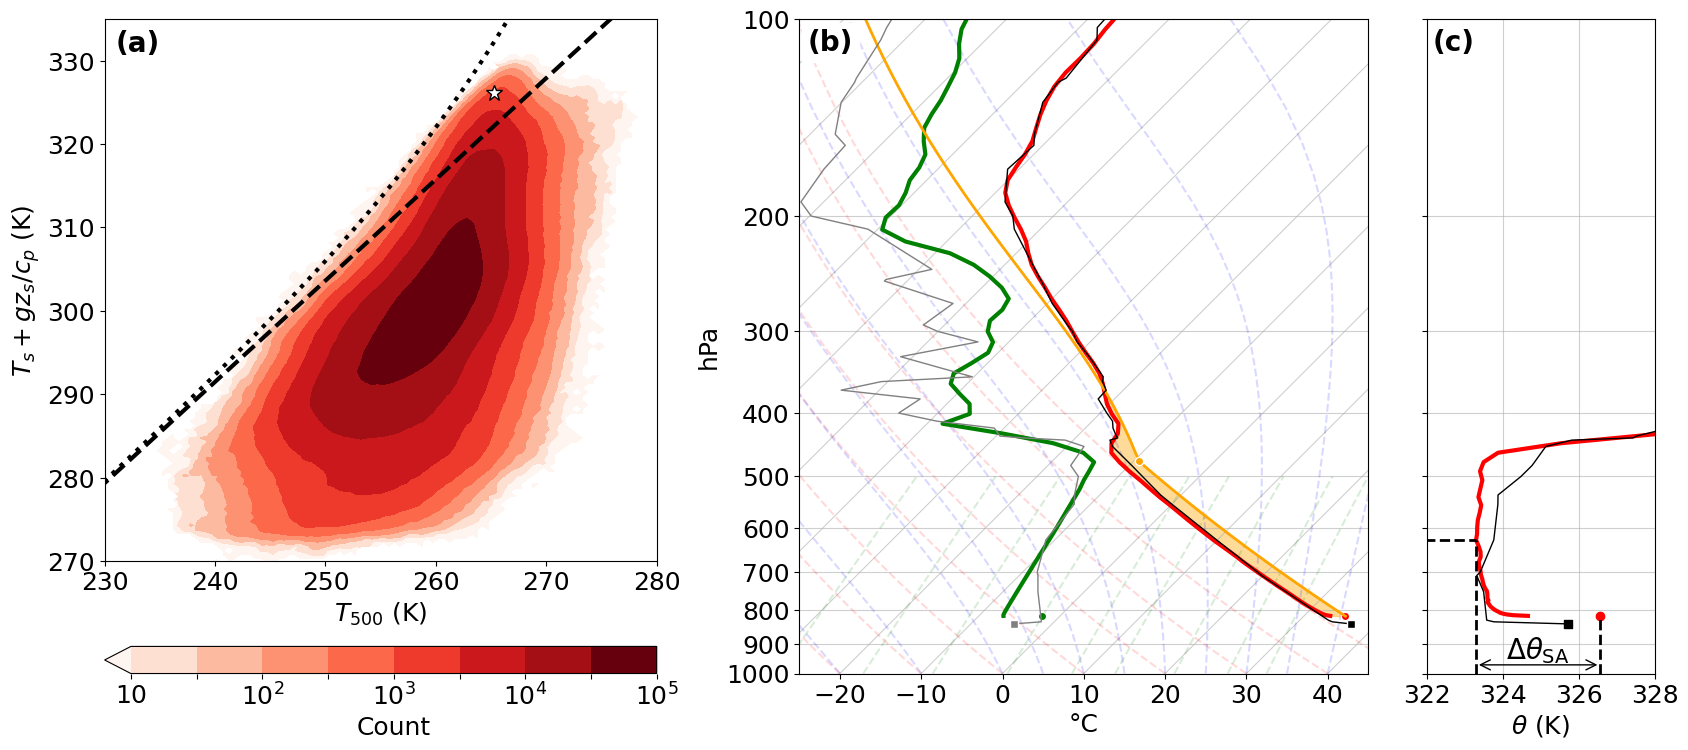

In [10]:
matplotlib.rcParams['font.size']=18; ftz=18
fig = plt.figure(figsize=(20,8.5))
gs = gridspec.GridSpec(2,4,figure=fig,height_ratios = [1,0.05],width_ratios = [0.85,0.1,1,0.35],wspace=.05,hspace=0.3)
ax_hist = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[1,0])
gs_prof = gs[:2,2]
ax2 = fig.add_subplot(gs[:2,3])


######## Histogram ######## 
ax = ax_hist
hist = hist_dse_t500.where(hist_dse_t500>0)
c = hist.plot.contourf(ax=ax,cmap = plt.cm.Reds,levels = 10**np.arange(1,5.1,0.5),x="T500", add_colorbar=False)

cbar = fig.colorbar(c,cax=cax,orientation = 'horizontal',label='Count')
cbar.ax.set_xticklabels([r"$10$","",r"$10^2$","",r"$10^3$","",r"$10^4$","",r"$10^5$"]);

T500range = np.linspace(220,280,101)

ax.plot(T500range,calc_dry_upper_bound(T500range),color='k',ls='--',lw=3)
ax.plot(T500range,calc_ZB23_upper_bound(T500range),color='k',ls=':',lw=3)
ax.set_xlim(230,280)
ax.set_ylim(270,335)
ax.set_xlabel(r"$T_{500}$ (K)",fontsize=ftz)
ax.set_ylabel(r"$T_s + gz_s / c_p$ (K)",fontsize=ftz)

######## Skew-T ######## 
skew = pt.plot_skewT(fig, 
                     gs_prof, 
                     elko_era5.pressure.data,
                     elko_era5.T.data,
                     elko_era5.Q.data, 
                     elko_era5.PS.data/1e2,
                     elko_era5.T2M.data,
                     elko_era5.D2M.data)

skew.plot(elko_igra.pressure.data * units.hPa, elko_igra.T.data * units.degK, color = 'k',linewidth=1.,linestyle='-')
skew.plot(elko_igra.pressure.data * units.hPa, elko_igra.Td.data * units.degK, color = 'gray',linewidth=1.,linestyle='-')
skew.plot(elko_igra.pressure.data[0] * units.hPa, elko_igra.T.data[0] * units.degK, 's', color='w', markerfacecolor='k')
skew.plot(elko_igra.pressure.data[0] * units.hPa, elko_igra.Td.data[0] * units.degK, 's', color='w', markerfacecolor='gray')

ax1 = skew.ax
ax1.set_ylabel("hPa")
ax1.set_xlabel("°C")
ax1.set_yticks(np.arange(100,1001,100))
ax1.set_xlim(-25,45)

###### Potential temperature plot ######
ax2.plot(elko_era5.THETA, elko_era5.pressure, color = 'r',linewidth=3.)
ax2.plot(elko_igra.THETA, elko_igra.pressure, color='k',linewidth=1.,linestyle='-')
theta2m = elko_era5.T2M * (elko_era5.PS / 1e5 )**(-kappa)
ax2.scatter(theta2m, elko_era5.PS.data/1e2, color='r',marker='o')
ax2.scatter(elko_igra.THETA[0], elko_igra.pressure[0], color='k',marker='s')

theta_min = elko_era5.THETA.min()
pres_min = elko_era5.pressure[elko_era5.THETA.argmin()]
ax2.plot([theta_min,theta_min],[1000.,pres_min], color='k',linestyle='--',linewidth=2)
ax2.plot([320,theta_min],[pres_min,pres_min], color='k',linestyle='--',linewidth=2)
ax2.plot([theta2m,theta2m],[1000.,elko_era5.PS.data/1e2], color='k',linestyle='--',linewidth=2)

ax2.set_xlim(322,328)
ax2.set_ylim(1000,100)
ax2.set_yscale('log')

ax2.set_yticks(range(100,1001,100),labels='')
ax2.set_xticks(np.arange(322,328.1,2.))
ax2.set_xlabel(r"$\theta$ (K)")

y0 = 970
ax2.text((theta_min+theta2m)/2,950, r"$\Delta \theta_\mathrm{SA}$",color='k',fontsize=20,fontweight='bold',horizontalalignment='center')
ax2.annotate("", xy=(theta_min,y0), xytext=(theta2m,y0),arrowprops=dict(arrowstyle="<->"), xycoords='data')#'axes fraction'

for ax in ax1,ax2:
    ax.set_title('')
    ax.grid(alpha=0.6)

ax2.set_ylabel('')

###### Add star on histograms ######
# Find T500 by interpolation of model level data
T500 = np.interp(500, elko_era5.pressure.data, elko_era5.T.data)
ax_hist.plot(T500,elko_era5.T2M + elko_era5.ZSFC / constants['cpd'], marker='*', color='k', markerfacecolor='w', markersize=12)

# Add (a), (b), (c) labels to the top left of each panel. make background white
ax_hist.text(0.02, 0.98, '(a)', transform=ax_hist.transAxes, fontsize=20, fontweight='bold', va='top',backgroundcolor='w')
ax1.text(0.015, 0.985, '(b)', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top',backgroundcolor='w')
ax2.text(0.025, 0.985, '(c)', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')

# fig.savefig('figs/hist_with_profile.pdf',format='pdf',bbox_inches='tight')

# Figure 3: Superadiabatic layer strength characteristics

In [11]:
Elko = gt.Station('Elko',40.86,-115.74, DATA_PATH)
SLC = gt.Station('SLC',40.77,-111.96, DATA_PATH)
Riverton = gt.Station('Riverton',43.06,-108.48, DATA_PATH)

In [12]:
for station in Elko, SLC, Riverton:
    print(station.name)
    print("# Missing data:", np.isnan(station.igra.PBL_HPA_richardson).sum().data)

Elko
# Missing data: 2
SLC
# Missing data: 7
Riverton
# Missing data: 4


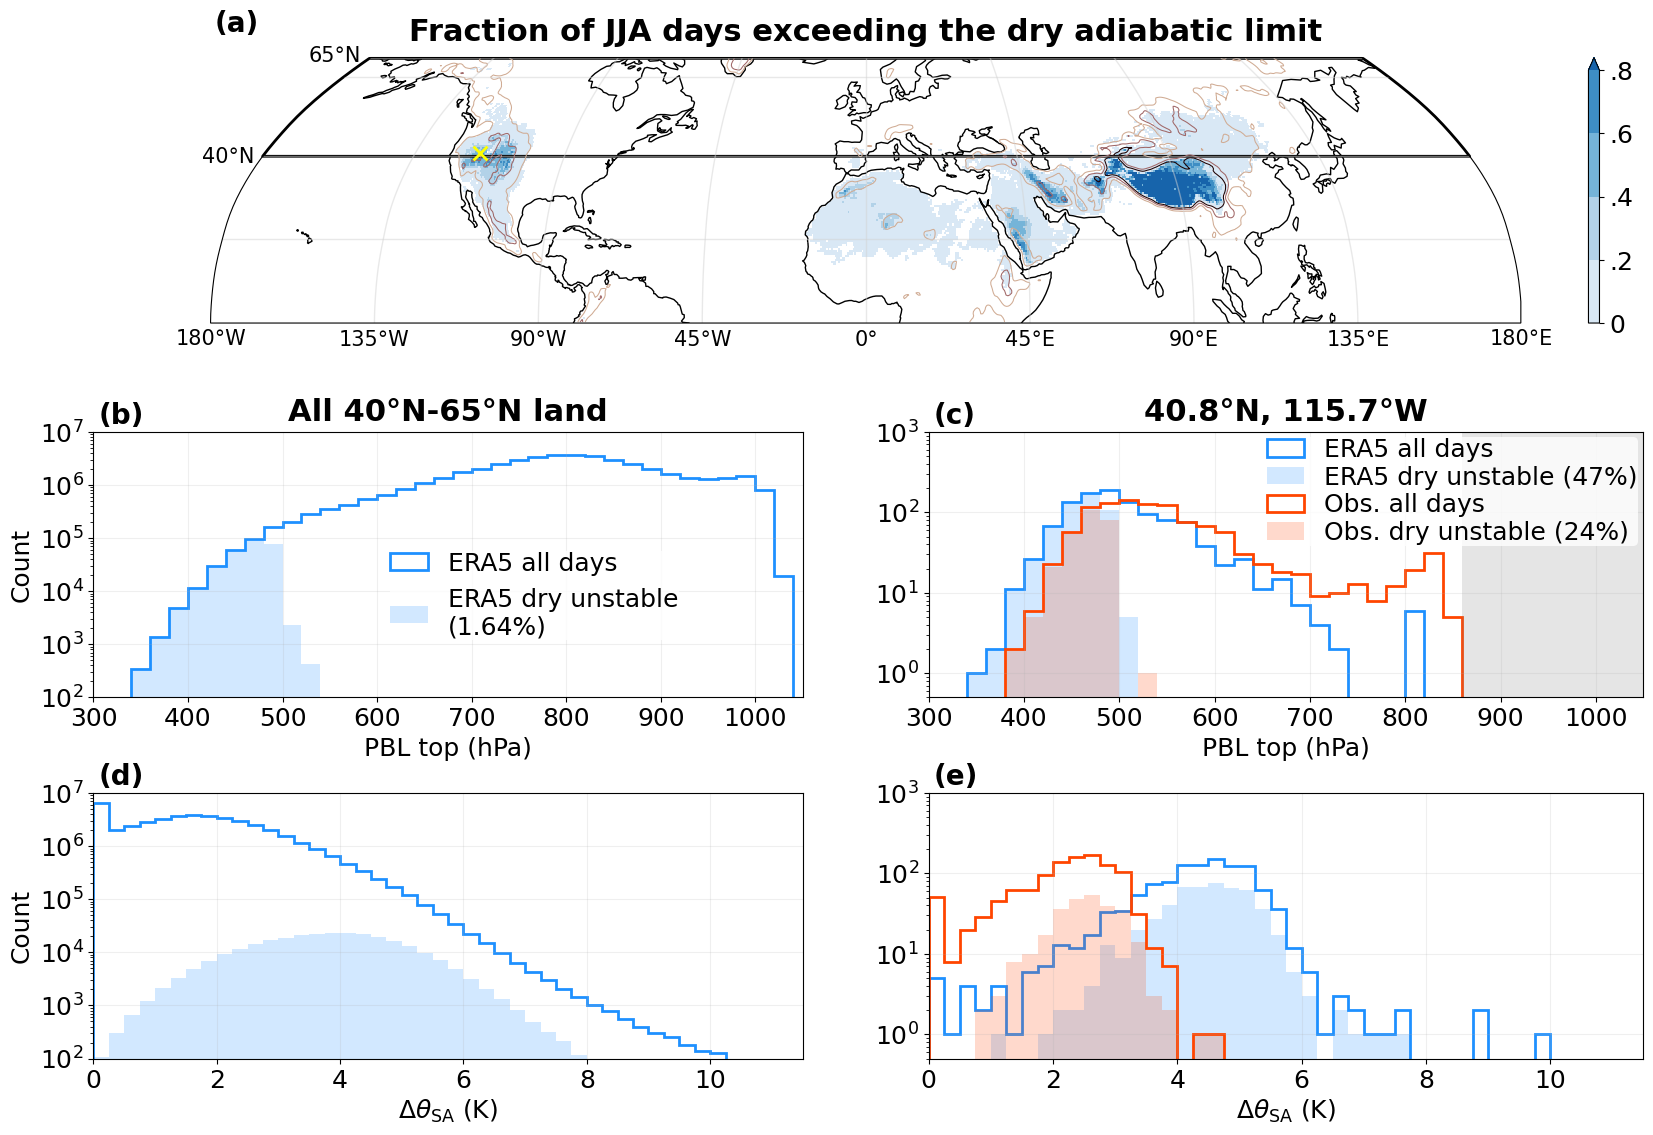

In [13]:
matplotlib.rcParams['font.size']=18
ttl_size = 22
fig = plt.figure(figsize=(20,13))

space_mid = 0.08
cbar_frac = 0.007
map_blank = 0.1
cbar_pad = (map_blank - cbar_frac)/2
blankfrac = 0.4
gs = gridspec.GridSpec(5, 7, figure=fig, 
                       width_ratios = [map_blank-0.05,0.5-map_blank,space_mid,0.5-map_blank,blankfrac * cbar_pad,cbar_frac,(1-blankfrac) * cbar_pad],
                       height_ratios=[1.,0.15,1,0.1,1],
                       wspace=0.)
ax_map = fig.add_subplot(gs[0,1:4],projection=ccrs.Robinson())
ax_cbar = fig.add_subplot(gs[0,-2])
axs = np.array([[fig.add_subplot(gs[2,:2]),fig.add_subplot(gs[2,3:])],
                [fig.add_subplot(gs[4,:2]),fig.add_subplot(gs[4,3:])]])
axs = axs.transpose()

###########################################################################
################################### MAP ###################################
###########################################################################
colors = plt.cm.pink_r(np.linspace(0.5, 1.0, 1001))
pink_r_trunc = ListedColormap(colors)
colors = plt.cm.Blues(np.linspace(0.15, 0.8, 1001))
Blues_trunc = ListedColormap(colors)

dry_bound_exceedance = merged_t2max_global.THETA2M > calc_dry_upper_bound_theta(merged_t2max_global.T500)
dry_bound_exceedance_locs = dry_bound_exceedance.sel(lat=slice(0,65)).mean('time')
dry_bound_exceedance_locs = dry_bound_exceedance_locs.where(dry_bound_exceedance_locs>0)
c = dry_bound_exceedance_locs.plot(ax=ax_map,transform=ccrs.PlateCarree(),cmap=Blues_trunc,levels = np.arange(0.,0.81,0.2),add_colorbar=False)

topography_smooth = gt.smooth(zsfc/9.81,1.).sel(lat=slice(0,65))
topography_smooth.plot.contour(ax=ax_map,transform=ccrs.PlateCarree(),levels=[1000,2000,3000],cmap = pink_r_trunc,linewidths = .75)

ax_map.coastlines()
ax_map.set_title('Fraction of JJA days exceeding the dry adiabatic limit', fontweight='bold',fontsize=ttl_size,pad =12)

fig.colorbar(c, cax = ax_cbar, ticks = np.arange(0.,0.81,0.2))#,**{'orientation': 'horizontal'})
ax_cbar.set_yticklabels(['0','.2','.4','.6','.8'])

gl = ax_map.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1,color='lightgrey',linestyle='-',alpha=0.5)
gl.ylocator = mticker.FixedLocator([20,40,60,65])
gl.xlocator = mticker.FixedLocator(np.arange(-135,136,45))
# add latitude and longitude labels with LongitudeFormatter and LatitudeFormatter. import first:
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.right_labels = False
label_ftz = 15
gl.xlabel_style = {'size': label_ftz}; gl.ylabel_style = {'size': label_ftz}

# Fix cartopy label bug - add white square to cover one label and add missing label
ax_map.add_patch(plt.Rectangle((0.89, 0.97), 0.04, 0.15, transform=ax_map.transAxes, color='w', zorder=10,clip_on=False))
ax_map.add_patch(plt.Rectangle((0.91, 0.905), 0.04, 0.15, transform=ax_map.transAxes, color='w', zorder=10,clip_on=False))
ax_map.add_patch(plt.Rectangle((-0.038, 0.23), 0.04, 0.15, transform=ax_map.transAxes, color='w', zorder=10,clip_on=False))
ax_map.add_patch(plt.Rectangle((0.049, 0.9), 0.04, 0.07, transform=ax_map.transAxes, color='w', zorder=10,clip_on=False))

ax_map.text(0., -0.02, '180°W', transform=ax_map.transAxes, va='top', ha = 'center',fontsize = label_ftz)
ax_map.text(1., -0.02, '180°E', transform=ax_map.transAxes, va='top', ha = 'center',fontsize = label_ftz)
ax_map.text(0.115, 0.97, '65°N', transform=ax_map.transAxes, va='bottom', ha = 'right',fontsize = label_ftz)

# Add station location
ax_map.scatter(Elko.lon, Elko.lat, marker='x', color='yellow',transform=ccrs.PlateCarree(),linewidths=2, zorder=10,s=100)

######## ADD THICKER FRAME AROUND MAP ##########
lat_min, lat_max = 40, 65
lon_min, lon_max = -180, 180

coords = [
    (lon_min, lat_min),
    (lon_max, lat_min),
    (lon_max, lat_max),
    (lon_min, lat_max),
]

poly = Polygon(coords)

feat = cfeature.ShapelyFeature([poly], ccrs.PlateCarree(), 
                               edgecolor='k', facecolor='none',clip_on=False)
ax_map.add_feature(feat, linewidth=2.)

###########################################################################
############################### HISTOGRAMS ################################
###########################################################################

bins_pbl = np.arange(300,1061,20)
bins_SA = np.arange(0.,12.1,0.25)

colors = ['dodgerblue','dodgerblue','orangered','orangered']

alpha0 = 0.
alpha = 0.2

# All data
for ax,bins,data in zip(axs[0],[bins_pbl,bins_SA],[PBL_HPA,superadibatic_strength_2m]):
    test = mcolors.to_rgb(colors[0]) + (alpha0,)
    ax.hist(gt.sel_cond(data, lsm), 
            bins = bins,
            label='ERA5 all days',
            edgecolor=colors[0], 
            facecolor = mcolors.to_rgb(colors[1]) + (alpha0,),
            lw = 2, 
            histtype='stepfilled')
    ax.hist(gt.sel_cond(data, dry_bound_exceedance * lsm), 
            bins = bins,
            label=f'ERA5 dry unstable\n({100 * dry_bound_exceedance.where(lsm).mean():.2f}%)',
            edgecolor=None, 
            facecolor = mcolors.to_rgb(colors[1]) + (alpha,),
            lw = 2,
            histtype='stepfilled')


# Elko data
cond = Elko.era5_where_igra_valid.THETA2M > calc_dry_upper_bound_theta(Elko.era5_where_igra_valid.T500)
cond_soundings = Elko.igra.theta.isel(lev=0) > calc_dry_upper_bound_theta(Elko.igra.T500)
for ax,bins,datae5,datasounding in zip(axs[1],
                                       [bins_pbl,bins_SA],
                                       [Elko.era5_where_igra_valid.PBL_HPA_2m, Elko.era5_where_igra_valid.superadibatic_strength_2m],
                                       [Elko.igra.PBL_HPA_richardson, Elko.igra.superadibatic_strength],
                                       ):
    ax.hist(datae5, bins = bins,label='ERA5 all days',edgecolor=colors[0], facecolor = mcolors.to_rgb(colors[0]) + (alpha0,),lw = 2, histtype='stepfilled')
    ax.hist(gt.sel_cond(datae5, cond), bins = bins,label=f'ERA5 dry unstable ({100 * cond.mean():.0f}%)',edgecolor=None, facecolor = mcolors.to_rgb(colors[1]) + (alpha,),lw = 2, histtype='stepfilled')

    ax.hist(datasounding, bins = bins,label='Obs. all days',edgecolor=colors[2], facecolor = mcolors.to_rgb(colors[2]) + (alpha0,),lw = 2, histtype='stepfilled')
    ax.hist(gt.sel_cond(datasounding, cond_soundings), bins = bins,label=f'Obs. dry unstable ({100 * cond_soundings.mean():.0f}%)',edgecolor=None, facecolor = mcolors.to_rgb(colors[3]) + (alpha,),lw = 2, histtype='stepfilled')

ps_max = Elko.igra.pressure.isel(lev=0).max().data/100
axs[1,0].fill_between(bins_pbl, 1e-1,1e3, where= bins_pbl>ps_max, alpha=0.2,ec='none',fc='grey')

for ax in axs.flatten():
    ax.grid(alpha=0.2)
    ax.set_yscale('log')
for i in range(2):
    axs[i,0].set_xlim(300,1050)
    axs[i,1].set_xlim(0,11.5)
    hl=1.5
    legend_args = dict(borderpad=0.03,loc='upper left', bbox_to_anchor=(0.4, 0.6), handlelength=hl) if i==0 else dict(labelspacing=0.15,borderpad=0.03,borderaxespad=0.2, handlelength=hl)
    legend = axs[i,0].legend(**legend_args)
    legend.get_frame().set_edgecolor('none')


    axs[i,0].set_xlabel('PBL top (hPa)')
    axs[i,1].set_xlabel(r'$\Delta\theta_\mathrm{SA}$ (K)')

    
    axs[0,i].yaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
    axs[0,i].set_ylim(1e2,1e7)
    axs[1,i].set_ylim(.5,1e3)
    axs[0,i].set_yticks(10**np.arange(2,7.1,1))

    axs[0,i].set_ylabel('Count')

axs[0,0].set_title('All 40°N-65°N land',fontweight='bold',fontsize=ttl_size,pad=8)
axs[1,0].set_title('40.8°N, 115.7°W',fontweight='bold',fontsize=ttl_size,pad=8)

ax_map.text(0.003, 1.18, '(a)', transform=ax_map.transAxes, fontsize=20, fontweight='bold', va='top', ha = 'left')
for ax,letter in zip(axs.transpose().flatten(),['(b)','(c)','(d)','(e)']):
    ax.text(0.007, 1.01, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha = 'left')

# fig.savefig('figs/superadiab_characteristics.pdf',format='pdf',bbox_inches='tight')


# Figure 4: Extended histogram

In [14]:
all65S65N = (lsm.lat <= 65) * (lsm.lat >= -65)
# Get joint histogram of T500 and DSE at 2m over midlatitude land points
hist_dse_t500_global = gt.get_hist(merged_t2max_global.T500,
                                   merged_t2max_global.T2M + zsfc/constants['cpd'],
                                   lsm * all65S65N, 
                                   dim_names=['T500','DSE2M'],
                                   bins = (np.arange(200,301,.5), np.arange(240,351,.5))
                                   )

Text(0.5, 0, '$T_{500}$ (K)')

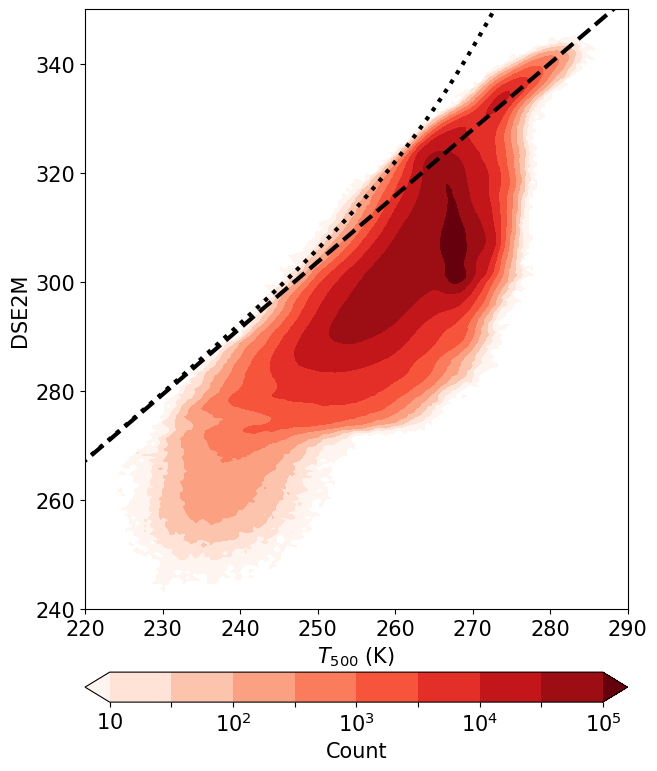

In [15]:
matplotlib.rcParams['font.size']=15; ftz=15
fig,(ax,cax) = plt.subplots(2,1,figsize=(7,9),height_ratios=[1,0.05])

c = hist_dse_t500_global.where(hist_dse_t500_global>0).plot.contourf(ax=ax,cmap = plt.cm.Reds,levels = 10**np.arange(1,5.1,0.5),x="T500",add_colorbar=False)

cbar = fig.colorbar(c,cax=cax,orientation = 'horizontal',label='Count')
cbar.ax.set_xticklabels([r"$10$","",r"$10^2$","",r"$10^3$","",r"$10^4$","",r"$10^5$"]);

T500range = np.linspace(210,290,101)

ax.plot(T500range,calc_dry_upper_bound(T500range),color='k',ls='--',lw=3)
ax.plot(T500range,calc_ZB23_upper_bound(T500range),color='k',ls=':',lw=3)

ax.set_xlim(220,290)
ax.set_ylim(240,350)
ax.set_xlabel(r"$T_{500}$ (K)",fontsize=ftz)
# fig.savefig('figs/extended_hist.pdf',format='pdf',bbox_inches='tight')

# Figure S1: PBL histograms

In [16]:
bins_pbl = np.linspace(300,1040,100)
cond_all = PBL_HPA_e5**0 # Array of ones to select all data points
hist_PBLtops = gt.get_hist(PBL_HPA_e5, 
                   PBL_HPA, 
                   cond_all,
                   dim_names = ['PBLtop_lml', 'PBLtop_2m'],
                   bins = (bins_pbl,bins_pbl))

Text(0.5, 1.0, '2-m based PBL top (hPa)')

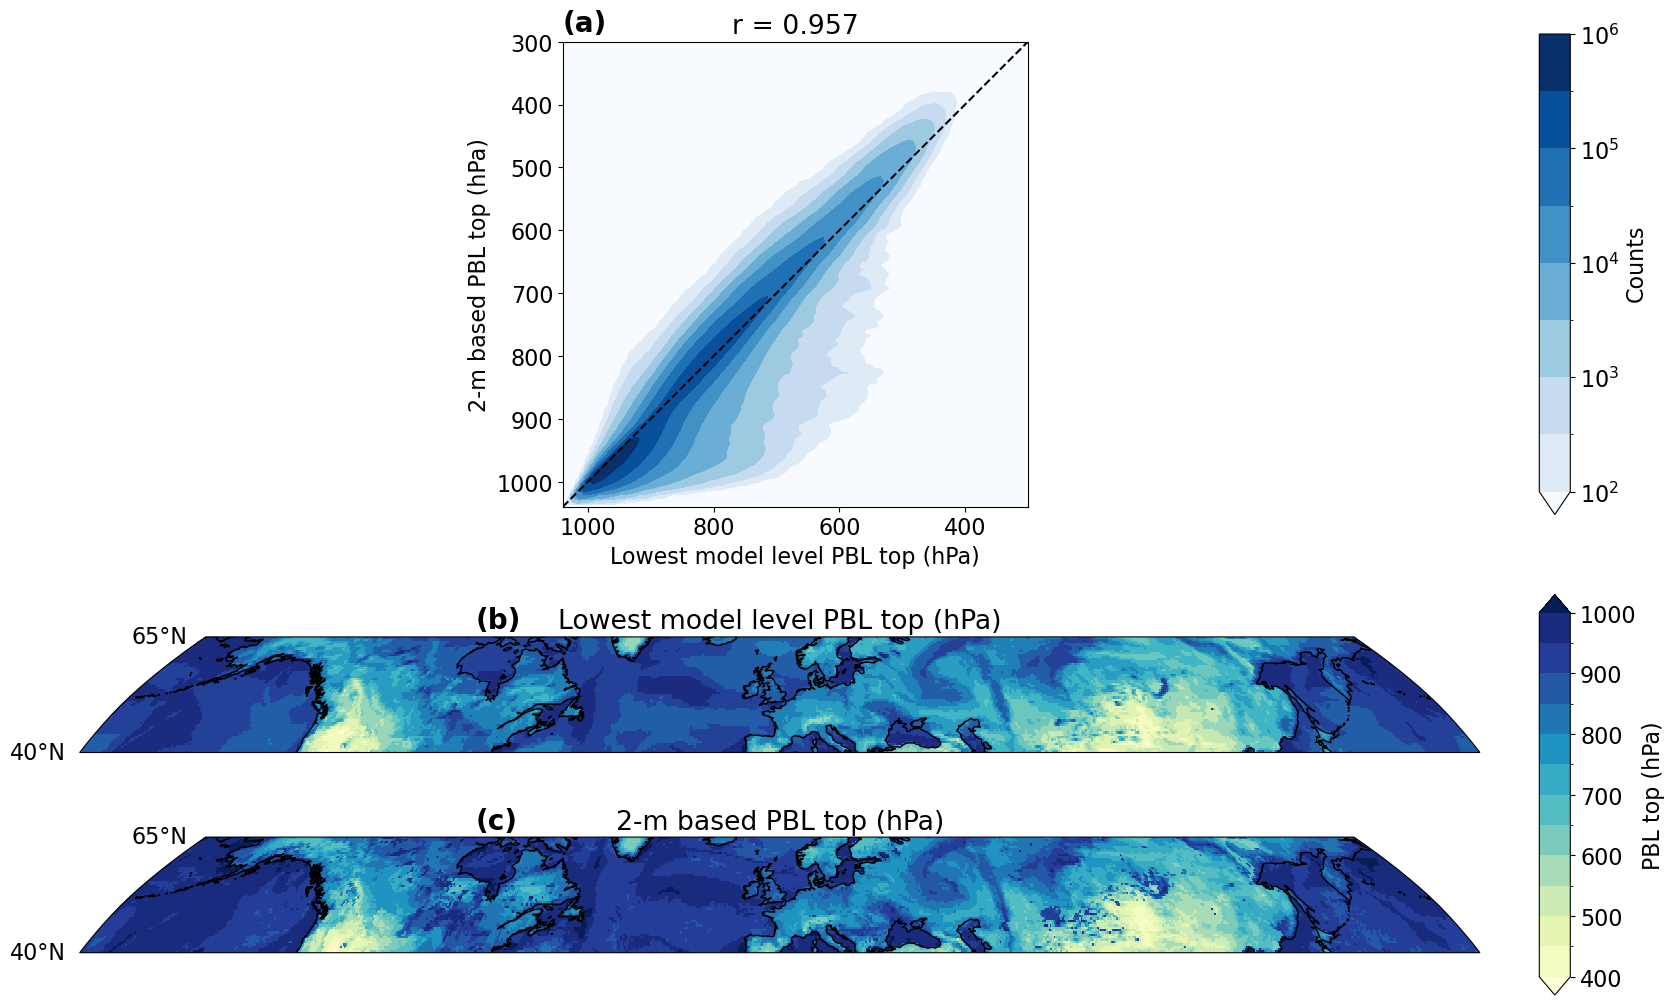

In [17]:
matplotlib.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(20,13))
histfrac = 0.3
eps = 0.02
gs = gridspec.GridSpec(6, 4, height_ratios=[0.2,2.4,0.2,0.2,1,1], width_ratios=[(1-histfrac)/2,histfrac,(1-histfrac)/2-eps,eps],wspace=0.,hspace=0.)

##### HISTOGRAM OF PBL TOPS #####
ax = fig.add_subplot(gs[:3,1])
cf = hist_PBLtops.transpose().plot.contourf(ax=ax,xincrease=False, yincrease=False,levels = 10**np.arange(2,6.1,0.5),add_colorbar=False,cmap='Blues')
ax.plot([1040,300],[1040,300],color='k',linestyle='--')
corr = np.corrcoef(PBL_HPA_e5.data.reshape(-1), PBL_HPA.data.reshape(-1))[0,1]
ax.set_title(f"r = {corr:.3f}")
ax.set_xlim([1040,300])
ax.set_ylim([1040,300])
ax.set_aspect('equal')
ax.set_xlabel('Lowest model level PBL top (hPa)')
ax.set_ylabel('2-m based PBL top (hPa)')

ax.text(0., 1.01, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha = 'left')

cax = fig.add_subplot(gs[1,-1])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.set_label('Counts')
cbar.set_ticks(10**np.arange(2,7))
cbar.set_ticklabels([f'$10^{{{i}}}$' for i in range(2,7)])

##### MAPS #####
lvls = np.arange(400,1050,50)
ax1 = fig.add_subplot(gs[4,:-1], projection=ccrs.Robinson())
PBL_HPA_e5.isel(time=0).plot(ax=ax1,transform=ccrs.PlateCarree(),cmap='YlGnBu',levels = lvls,add_colorbar=False)

ax2 = fig.add_subplot(gs[5,:-1], projection=ccrs.Robinson())
cf = PBL_HPA.isel(time=0).plot(ax=ax2,transform=ccrs.PlateCarree(),cmap='YlGnBu',levels = lvls,add_colorbar=False)

cax2 = fig.add_subplot(gs[4:,-1])
cbar2 = fig.colorbar(cf, cax=cax2, orientation='vertical')
cbar2.set_label('PBL top (hPa)')

for ax in [ax1,ax2]:
    ax.coastlines()
    ax.text(0.11,1.,'65°N',transform=ax.transAxes,ha='right',va='center')
    ax.text(0.03,0.,'40°N',transform=ax.transAxes,ha='right',va='center')

for ax,letter in zip([ax1,ax2],['(b)','(c)']):
    ax.text(0.3, 1.02, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha = 'left')

ax1.set_title('Lowest model level PBL top (hPa)')
ax2.set_title('2-m based PBL top (hPa)')


# Figure S2: three sounding locations

In [18]:
Elko = gt.Station('Elko',40.86,-115.74, DATA_PATH)
SLC = gt.Station('SLC',40.77,-111.96, DATA_PATH)
Riverton = gt.Station('Riverton',43.06,-108.48, DATA_PATH)

Elko 1124 1932
SLC 1352 1932
Riverton 1402 1932


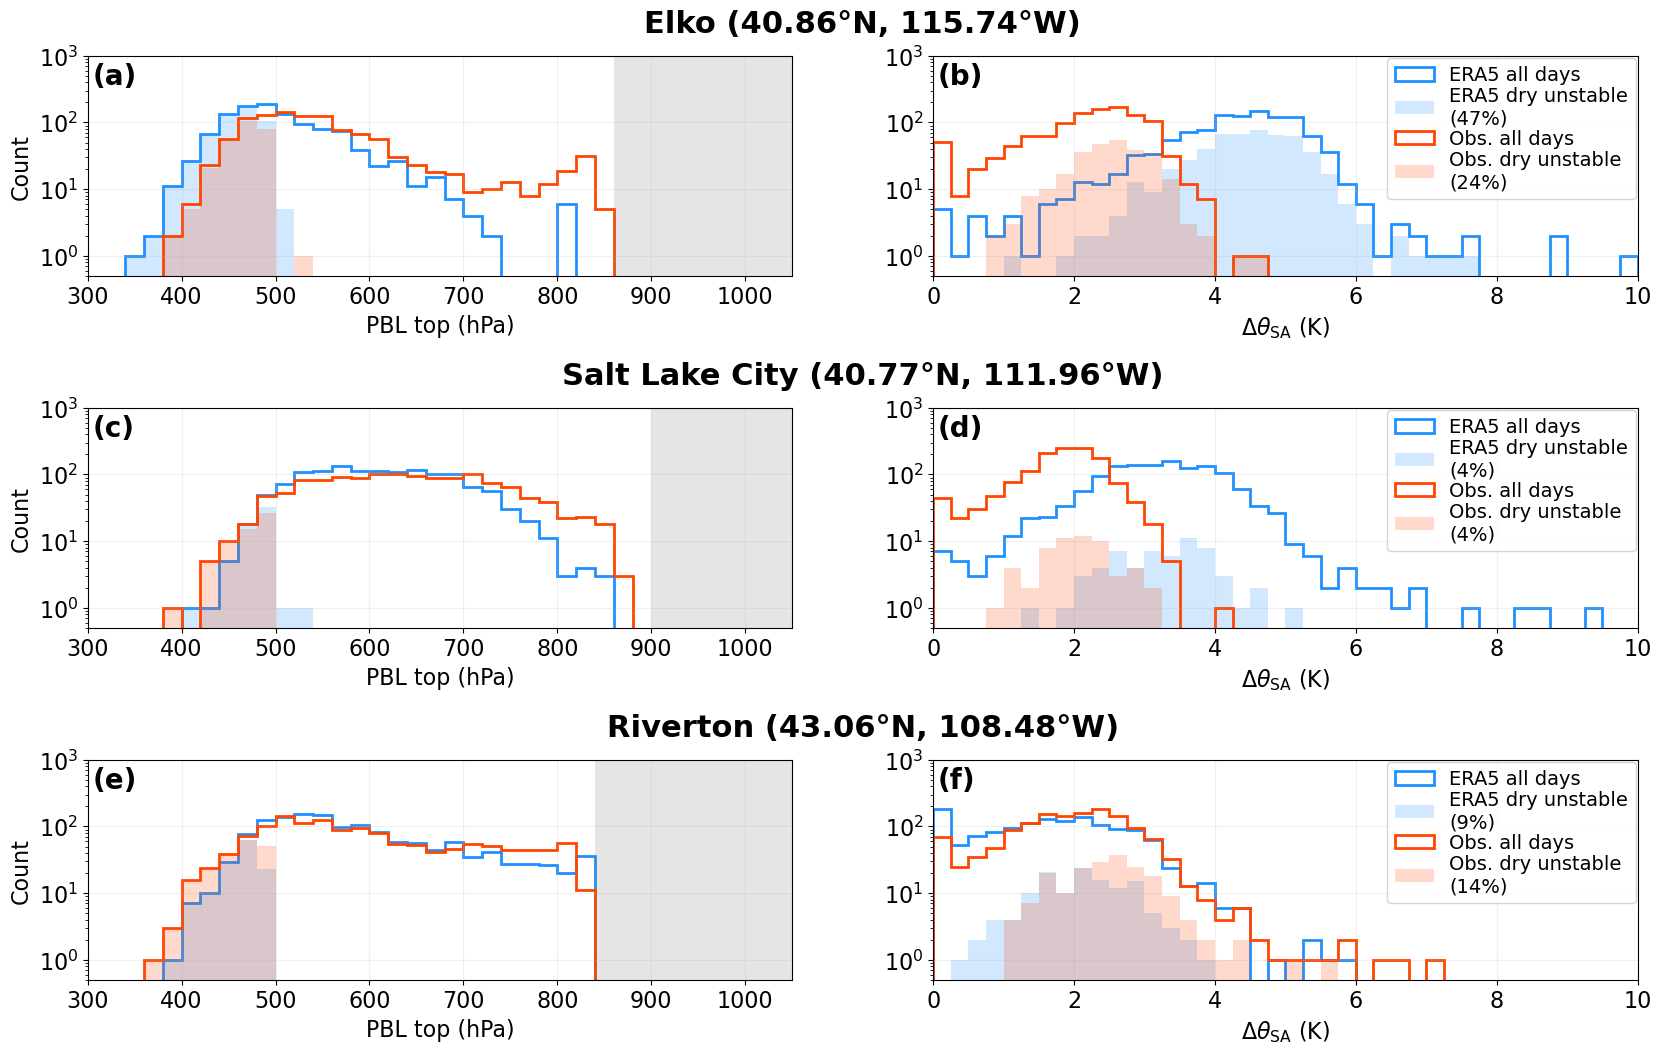

In [19]:
fig,axs =plt.subplots(3,2,figsize=(20,12))
matplotlib.rcParams['font.size']=18


bins_pbl = np.arange(300,1061,20)
bins_SA = np.arange(0.,10.1,0.25)

colors = ['dodgerblue','dodgerblue','orangered','orangered']

alpha0 = 0.
alpha = 0.2
ls = '-'

for i,station in enumerate([Elko, SLC, Riverton]):
    print(station.name, station.igra.time.size, station.era5.time.size)
    cond = station.era5_where_igra_valid.THETA2M > calc_dry_upper_bound_theta(station.era5_where_igra_valid.T500)
    cond_soundings = station.igra.theta.isel(lev=0) > calc_dry_upper_bound_theta(station.igra.T500)
    for ax,bins,datae5,datasounding in zip(axs[i],
                                        [bins_pbl,bins_SA],
                                        [station.era5_where_igra_valid.PBL_HPA_2m, station.era5_where_igra_valid.superadibatic_strength_2m],
                                        [station.igra.PBL_HPA_richardson, station.igra.superadibatic_strength],
                                        ):
        ax.hist(datae5, bins = bins,label='ERA5 all days',edgecolor=colors[0], facecolor = mcolors.to_rgb(colors[0]) + (alpha0,),lw = 2, histtype='stepfilled')
        ax.hist(gt.sel_cond(datae5, cond), bins = bins,label=f'ERA5 dry unstable\n({100 * cond.mean():.0f}%)',edgecolor=None, facecolor = mcolors.to_rgb(colors[1]) + (alpha,),lw = 2,ls = ls, histtype='stepfilled')

        ax.hist(datasounding, bins = bins,label='Obs. all days',edgecolor=colors[2], facecolor = mcolors.to_rgb(colors[2]) + (alpha0,),lw = 2, histtype='stepfilled')
        ax.hist(gt.sel_cond(datasounding, cond_soundings), bins = bins,label=f'Obs. dry unstable\n({100 * cond_soundings.mean():.0f}%)',edgecolor=None, facecolor = mcolors.to_rgb(colors[3]) + (alpha,),lw = 2,ls = ls, histtype='stepfilled')
            
    ps_max = station.igra.pressure.isel(lev=0).max().data/100
    axs[i,0].fill_between(bins_pbl, 1e-1,1e3, where= bins_pbl>ps_max, alpha=0.2,ec='none',fc='grey')

for ax in axs.flatten():
    ax.grid(alpha=0.2)
    ax.set_yscale('log')
    ax.set_ylim(.5,1e3)
for i in range(3):
    axs[i,0].set_xlim(300,1050)
    axs[i,1].set_xlim(0,10)
    axs[i,1].legend(fontsize=14,labelspacing=0.1,borderaxespad=0.1)
    axs[i,0].set_xlabel('PBL top (hPa)')
    axs[i,1].set_xlabel(r'$\Delta\theta_\mathrm{SA}$ (K)')
    axs[i,0].set_ylabel('Count')
fig.subplots_adjust(hspace=.6)

for ax,letter in zip(axs.flatten(),['(a)','(b)','(c)','(d)','(e)','(f)']):
    ax.text(0.007, 0.97, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha = 'left')
for ax, ttl in zip(axs[:,0], ['Elko (40.86°N, 115.74°W)','Salt Lake City (40.77°N, 111.96°W)','Riverton (43.06°N, 108.48°W)']):
    ax.text(1.1,1.08,ttl,fontweight='bold',fontsize=22,transform=ax.transAxes, va='bottom', ha = 'center')

# Figure S3: 300 hPa / 400 hPa -based histograms

In [20]:
midlats = (lsm.lat <= 65) * (lsm.lat >= 40)
# Get joint histogram of T400 and DSE at 2m over midlatitude land points
hist_dse_t400 = gt.get_hist(merged_T2mmax_midlats.T400,
                            (merged_t2max_global.T2M + zsfc/constants['cpd']).sel(lat=slice(40,65)),
                            (lsm * midlats).sel(lat=slice(40,65)), 
                            dim_names=['T400','DSE2M'],
                            bins = (np.arange(170,301,.5), np.arange(250,351,.5))
                            )

hist_dse_t300 = gt.get_hist(merged_T2mmax_midlats.T300,
                            (merged_t2max_global.T2M + zsfc/constants['cpd']).sel(lat=slice(40,65)),
                            (lsm * midlats).sel(lat=slice(40,65)), 
                            dim_names=['T300','DSE2M'],
                            bins = (np.arange(170,301,.5), np.arange(250,351,.5))
                            )

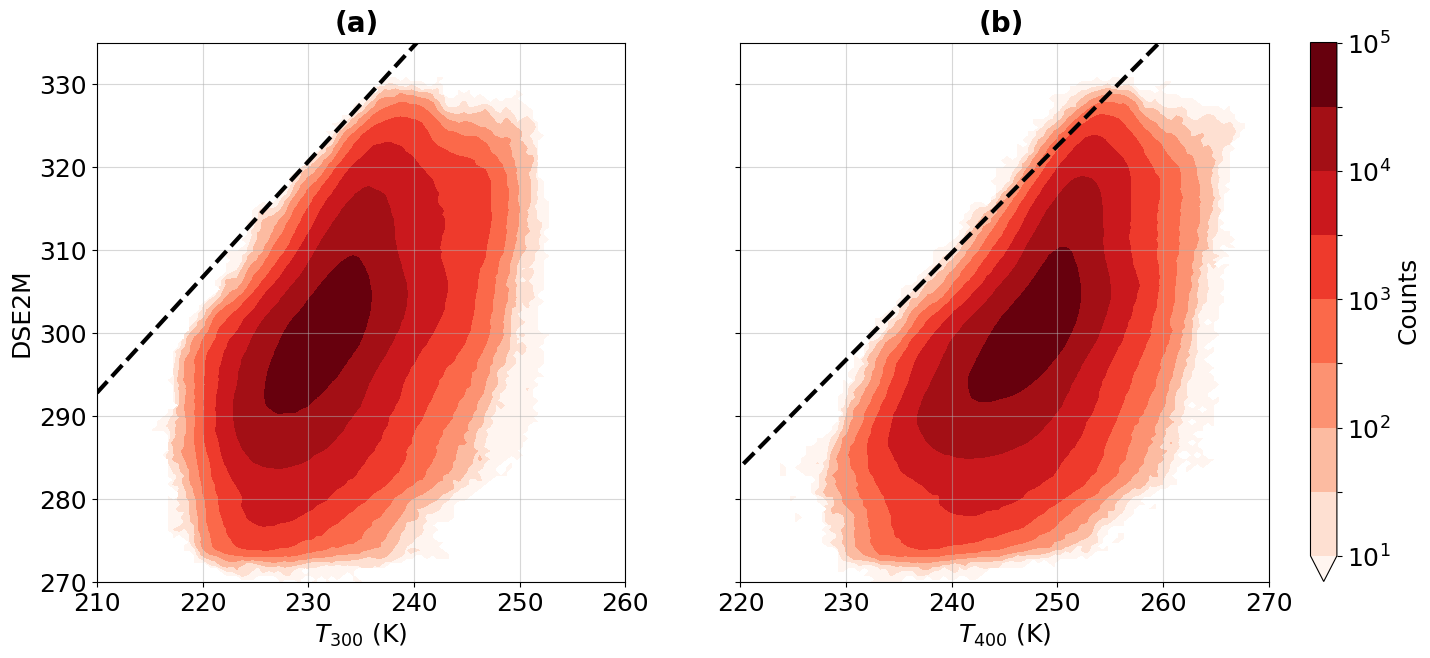

In [21]:
matplotlib.rcParams.update({'font.size': 18})

# use gridspec to create subplots with shared colorbar
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 4, width_ratios=[1,0.06,1,0.05],wspace=0.15)
axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[2])]
cax = fig.add_subplot(gs[-1])

# Store the contour plot handle from the first subplot for shared colorbar
cf = None

for ax, hist, desc in zip(
    axs,
    [hist_dse_t300, hist_dse_t400],
    [r'$T_{300}$ (K)', r'$T_{400}$ (K)'],
):
    cf = hist.where(hist>0).plot.contourf(ax=ax,cmap = plt.cm.Reds,levels = 10**np.arange(1,5.1,0.5),y="DSE2M",add_colorbar=False)
    ax.set_ylim(270,335)
    ax.set_xlabel(desc)
    ax.grid(alpha=.5)

axs[0].set_xlim(210,260)
axs[1].set_xlim(220,270)
axs[1].set_yticklabels('')
axs[1].set_ylabel('')

Trange = np.linspace(210,290,101)
axs[0].plot(Trange,calc_dry_upper_bound_300(Trange),color='k',ls='--',lw=3)
axs[1].plot(Trange,calc_dry_upper_bound_400(Trange),color='k',ls='--',lw=3)


# Add a single shared colorbar to the right
cbar = plt.colorbar(cf, cax=cax, orientation='vertical')
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.set_label("Counts")

for ax,letter in zip(axs,['(a)','(b)']):
    ax.text(0.45, 1.01, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha = 'left')



# Figure S4: Superadiabatic strength vs SSHF

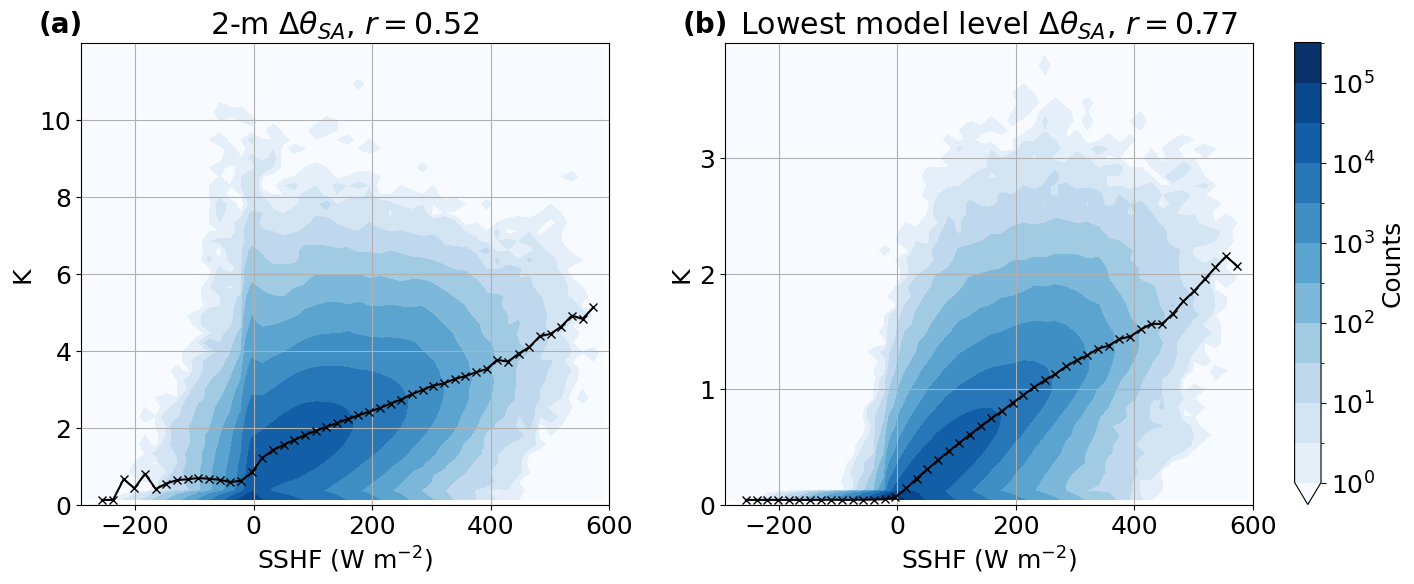

In [22]:
matplotlib.rcParams.update({'font.size': 18})

# use gridspec to create subplots with shared colorbar
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[1,0.06,1,0.05],wspace=0.15)
axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[2])]
cax = fig.add_subplot(gs[-1])

# Store the contour plot handle from the first subplot for shared colorbar
cf = None

for ax, superadibatic_strength, ttl, MM in zip(
    axs,
    [superadibatic_strength_2m, superadibatic_strength_lowestlev],
    [r'2-m $\Delta\theta_{SA}$', r'Lowest model level $\Delta\theta_{SA}$'],
    [12, 4]
):
    dims = ['SSHF', 'superadiabatic layer strength (K)']
    hist2d_xr = gt.get_hist(
        -sshf_2001 / 3600,
        superadibatic_strength[:92],
        lsm,
        dim_names=dims,
        bins=(np.linspace(-300, 600, 51), np.linspace(0, MM, 51))
    )

    levels = 10 ** np.arange(0, 6, 0.5)
    cf = hist2d_xr.plot.contourf(
        ax=ax,
        cmap=plt.cm.Blues,
        x=dims[0],
        add_colorbar=False,  # disable per-plot colorbars
        levels = 10**np.arange(0,6,.5)
    )

    condmean_strength = (hist2d_xr * hist2d_xr[dims[1]]).sum(dims[1]) / hist2d_xr.sum(dims[1])
    condmean_strength.plot.line(ax=ax, x=dims[0], marker='x', color='k')

    r = np.corrcoef(
        gt.sel_cond(superadibatic_strength[:92], lsm),
        gt.sel_cond(-sshf_2001, lsm)
    )[1, 0]
    ax.set_title(ttl + r", $r = %.2f$" % r)
    ax.grid()
    ax.set_xticks(np.arange(-200, 601, 200))
    ax.set_ylim(0, MM)
    ax.set_ylabel('K')
    ax.set_xlabel(r'SSHF (W m$^{-2}$)')
axs[0].set_yticks(range(0,12,2))
axs[1].set_yticks(range(4))

# Add a single shared colorbar to the right
cbar = plt.colorbar(cf, cax=cax, orientation='vertical')
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.set_label("Counts")

for ax,letter in zip(axs,['(a)','(b)']):
    ax.text(-0.08, 1.01, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha = 'left')



# Figure S5: Mean surface height in T500 - DSE2m phase space 

In [23]:
all65S65N = (lsm.lat <= 65) * (lsm.lat >= -65)
# Get histogram weighted by surface elevation
zsfc_m_broadcast = (merged_t2max_global.T500**0) * zsfc / constants['g']
hist_weighted = gt.get_hist(merged_t2max_global.T500,
                            merged_t2max_global.T2M + zsfc/constants['cpd'],
                            lsm * all65S65N, 
                            weights = zsfc_m_broadcast,
                            dim_names=['T500','DSE2M'],
                            bins = (np.arange(200,301,.5), np.arange(240,351,.5))
                            )

Text(0.5, 0, '$T_{500}$ (K)')

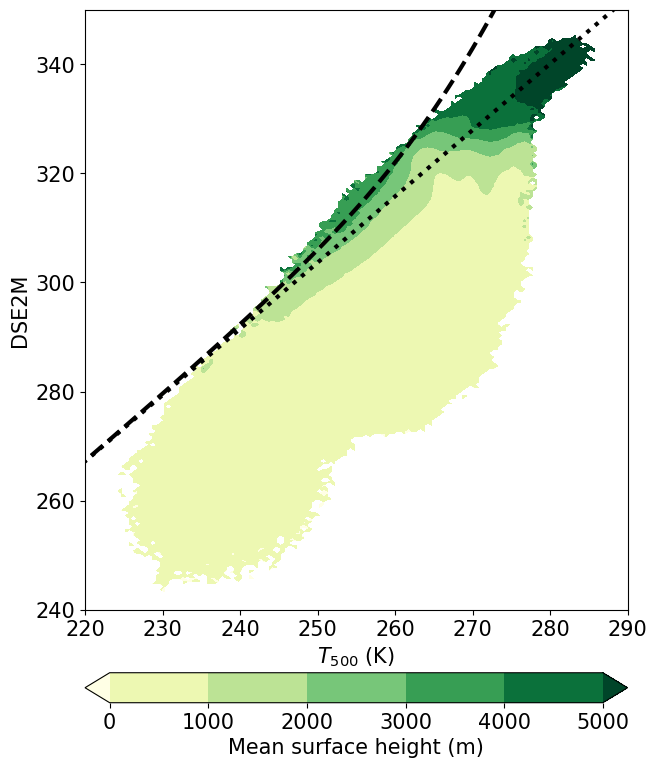

In [24]:
matplotlib.rcParams['font.size']=15; ftz=15
fig,(ax,cax) = plt.subplots(2,1,figsize=(7,9),height_ratios=[1,0.05])

mean_zsfc_binned = (hist_weighted / hist_dse_t500_global).where(hist_dse_t500_global>0)
c = mean_zsfc_binned.plot.contourf(ax=ax,
                                   cmap = plt.cm.YlGn,
                                   levels = np.arange(0,5.1,01.) * 1e3,
                                   x=r"T500",add_colorbar=False)

cbar = fig.colorbar(c,cax=cax,orientation = 'horizontal',label = 'Mean surface height (m)')

T500range = np.linspace(210,290,101)

ax.plot(T500range,calc_dry_upper_bound(T500range),color='k',ls=':',lw=3)
ax.plot(T500range,calc_ZB23_upper_bound(T500range),color='k',ls='--',lw=3)

ax.set_xlim(220,290)
ax.set_ylim(240,350)
ax.set_xlabel(r"$T_{500}$ (K)",fontsize=ftz)